# Updating probe and object

In [5]:
import importlib
import vector_ptycho.utils as vpu
importlib.reload(vpu)
from vector_ptycho.utils import *
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle


In [6]:
RGB_scale = make_vector_color_map(plot=False)

## Define the object, probe, fluence and XMLD constants

In [7]:
H, W = 100, 100
Lx = 10
Ly = 10

# Build theta, phi from meron-antimeron generator (returns torch tensors)
theta, phi, Mx, My, Mz = make_meron_antimeron_theta_phi(
    Nx=W,
    Ny=H,
    Lx=Lx,
    Ly=Ly,
    plot=False,
    save_path=None,
    export_path=None,
    return_torch=True,
    out_device=device,
    cm = RGB_scale,
)

# Physical XMLD/Jones constants
C = torch.tensor(50.0+ 50.0j, dtype=cdtype, device=device)
A1 = torch.tensor(0.5 + 5j, dtype=cdtype, device=device)
A2 = torch.tensor(0.8 + 5j, dtype=cdtype, device=device)

# Build Jones object from theta, phi
neel = NeelObject(C, A1, A2)
J = neel.build_jones(theta, phi)
obj = JonesObject(J)

# Grid for probe definition
x = torch.linspace(-Lx, Lx, H, device=device)
y = torch.linspace(-Ly, Ly, W, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')

fluence = torch.scalar_tensor(1e6, dtype=torch.float64, device=device)
R=torch.sqrt(X**2+Y**2) #This helps with defining the probe

Diffuser = 0.8*(torch.sin(1*R)+torch.cos((Y*1+X*1)-0.8*(X-0.2))+torch.cos((Y-X)-0.4*(X))) #(torch.sqrt(3*X**2+1.5*Y**2)+torch.pi/3)#*(torch.exp(-0.1*R)) #np.mod(0.1*(torch.sin(150*R)+torch.cos((Y*10+X*30)**2-0.8*(X*75-0.2))+torch.cos((Y*10-X*33)**2-0.4*(X*50-0.2))),1)

P = torch.zeros_like(R)
P = torch.exp(2j*np.pi*Diffuser)*(torch.exp(-0.8*R))


probes = []
# Calculate the Jones vectors of the probes for different Linear polarisation states
pol_angles = [0, 30, 60, 90]
for angle in pol_angles:
    rad = np.deg2rad(angle)
    jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
    print(f'Jones vector for {angle} deg linear polarisation: {jones_vec}')
    probes.append(Probe(P, jones_vec, fluence=fluence, normalized=False))

print('Defined {} probes with different linear polarisation states.'.format(len(probes)))


#plot_probe_maps(probes[0].amplitude, Lx, Ly)
print('Probe fluence:', probes[0].fluence)

Jones vector for 0 deg linear polarisation: tensor([1.+0.j, 0.+0.j])
Jones vector for 30 deg linear polarisation: tensor([0.8660+0.j, 0.5000+0.j])
Jones vector for 60 deg linear polarisation: tensor([0.5000+0.j, 0.8660+0.j])
Jones vector for 90 deg linear polarisation: tensor([6.1232e-17+0.j, 1.0000e+00+0.j])
Defined 4 probes with different linear polarisation states.
Probe fluence: tensor(1000000., dtype=torch.float64)


# Define the scan trajectory, simulate the detector

In [8]:
xshiftvec = torch.linspace(-5, 5,15)
yshiftvec = torch.linspace(-5, 5,15)

# Shifting the text so that we can plot on the data
dx = (xshiftvec[1] - xshiftvec[0]) / 10
dy = (yshiftvec[1] - yshiftvec[0]) / 10

# Lab-coordinate scan grid used for plotting
xpos_lab, ypos_lab = torch.meshgrid(xshiftvec, yshiftvec, indexing="ij")
positions = torch.stack([ypos_lab.flatten(), xpos_lab.flatten()], dim=1)

# Convert lab coordinates into discrete pixel shifts for torch.roll(row, col)
pixel_size_y = (2 * Ly) / (H - 1)
pixel_size_x = (2 * Lx) / (W - 1)
positions_idx = torch.stack([
    torch.round(positions[:, 0] / pixel_size_y),
    torch.round(positions[:, 1] / pixel_size_x),
], dim=1).to(torch.int64)

scan = ScanTrajectory(positions_idx)

# Forward model
model = ForwardModel(obj, Propagator(), Detector(add_poisson_noise=True))
I_sim = model.simulate_all(probes, scan)
print('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)

C:\Users\godfrey\OneDrive - Nexus365\Documents\Google Drive (old computer 12_07_2022)\PhD\Year 3\Term 1\Ptycho\vector-ptycho\src\vector_ptycho\utils.py:356: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.positions = torch.tensor(positions, device=device)


Simulated data shape: torch.Size([4, 225, 100, 100])


# Generate a plot that can be updated

In [21]:
from IPython.display import display

from vector_ptycho.utils import _to_numpy


def create_live_plotter(Lx, Ly,
                       positions=None,
                       theta_cmap='magma',
                       phi_cmap=RGB_scale,
                       dx=0.0, dy=0.0,
                       show_positions=False,
                       label_positions=False,
                       label_axes=True):
    
    '''
    Generates a plotting function that can be called with new probe amplitude, theta, phi, and loss values to update the visualisation in real-time.

    Use by creating an empty plot:
    plot_update = create_live_plotter(Lx, Ly)
    Then update it after every few ptycho iterations:
    plot_update(probe, theta, phi, loss)

    '''

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.ravel()

    ax_amp   = axes[0]
    ax_phase = axes[1]
    ax_theta = axes[2]
    ax_phi   = axes[3]
    ax_loss  = axes[4]

    # Hide unused 6th subplot
    axes[5].axis('off')

    # --- Initial dummy data ---
    dummy = np.zeros((10, 10))

    im_amp = ax_amp.imshow(dummy, extent=[-Lx, Lx, -Ly, Ly],
                           origin='lower', cmap='magma')
    cbar_amp = fig.colorbar(im_amp, ax=ax_amp)
    ax_amp.set_title("Probe Amplitude")

    im_phase = ax_phase.imshow(dummy, extent=[-Lx, Lx, -Ly, Ly],
                               origin='lower', cmap='twilight')
    cbar_phase = fig.colorbar(im_phase, ax=ax_phase)
    ax_phase.set_title("Probe Phase")

    im_theta = ax_theta.imshow(dummy, extent=[-Lx, Lx, -Ly, Ly],
                               origin='lower', cmap=theta_cmap,
                               vmin=0, vmax=1)
    cbar_theta = fig.colorbar(im_theta, ax=ax_theta)
    ax_theta.set_title(r"$l_z$ heatmap")

    im_phi = ax_phi.imshow(dummy, extent=[-Lx, Lx, -Ly, Ly],
                           origin='lower', cmap=phi_cmap,
                           vmin=0, vmax=180)
    cbar_phi = fig.colorbar(im_phi, ax=ax_phi)
    cbar_phi.set_ticks([0, 30, 60, 90, 120, 150, 180])
    ax_phi.set_title(r"$\phi$ heatmap")

    loss_line, = ax_loss.plot([], [])
    ax_loss.set_title("Loss vs iteration")
    ax_loss.set_xlabel("Iteration")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_yscale('log')
    
    loss_history = []

    display_handle = display(fig, display_id=True)

    # --- Optional positions ---
    if positions is not None:
        pos = np.asarray(positions[:, :2])
    else:
        pos = None

    def update(probe_amplitude, theta, phi, loss):
        probe_amplitude_np = _to_numpy(probe_amplitude)
        theta_np = _to_numpy(theta)
        phi_np   = _to_numpy(phi)


        # --- Probe ---
        im_amp.set_data(np.abs(probe_amplitude_np))
        im_phase.set_data(np.angle(probe_amplitude_np))

        # --- Theta ---
        theta_plot = np.abs(np.cos(theta_np))
        im_theta.set_data(theta_plot)

        # --- Phi ---
        phi_deg = np.rad2deg(phi_np)
        phi_plot = np.mod(phi_deg, 180)
        im_phi.set_data(phi_plot)

        # --- Loss ---
        loss_history.append(_to_numpy(loss))
        loss_line.set_data(range(len(loss_history)), loss_history)
        ax_loss.relim()
        ax_loss.autoscale_view()

        # --- Overlay positions (only once ideally, but safe here) ---
        if show_positions and pos is not None:
            for ax in [ax_theta, ax_phi]:
                ax.scatter(pos[:, 1], pos[:, 0],
                           c='cyan', marker='x', s=12)

        display_handle.update(fig)

    return update

In [24]:
def optimize_object_and_probe_with_scheduler(scan, pol_angles, I_meas, H, W, initial_theta, initial_phi, initial_probe_amplitude,num_iterations=100, device=None):
    """
    Reconstruct probes (different for each polarisation) theta, phi, C, A1, A2 from measured diffraction patterns.
    This is an old function, a better batch-based approach is now being used and is absorbed into the Reconstruction Class.
    Parameters
    ----------
    scan : ScanTrajectory
        Scan positions.
    I_meas : torch.Tensor
        Measured intensities, shape (N_probes, N_scan, Hdet, Wdet)
    H, W : int
        Object map size.
    num_iterations : int
        Number of optimization steps.
    device : torch.device or str
        Device to use.
    """
    if device is None:
        device = I_meas.device

    # This is for the live plot updates
    plot_update = create_live_plotter(Lx, Ly)

    eps = 1e-12
    cdtype = torch.complex64

    # Learnable parameters
    theta = torch.nn.Parameter(initial_theta)
    phi   = torch.nn.Parameter(initial_phi)
    probe_amplitude = initial_probe_amplitude

    # Initialise the probe array (same for all pol states at the moment)
    probes = []
    for angle in pol_angles:
        rad = np.deg2rad(angle)
        jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
        probes.append(Probe(probe_amplitude, jones_vec, fluence=fluence, normalized=False))
    probe_amplitude = torch.nn.Parameter(probes[0].amplitude)
    probe_amplitude_start = probes[0].amplitude
    fluence_calc = torch.sum(torch.abs(probe_amplitude_start)**2)
    print(f"Calculated initial fluence from probe amplitude: {fluence_calc.item():.6e}, target fluence: {fluence.item():.6e}")

    optimizer = torch.optim.Adam([
        {"params": [theta], "lr": 5e-1},
        {"params": [phi], "lr": 5e-1},
        {"params": [C, A1, A2], "lr": 1e-5},
        {"params": [probe_amplitude], "lr": 60e-1}
        ])
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,       # reduce LR by 2x
        patience=5,      # wait 5 iterations without improvement
        threshold=1e-3,   # minimum change to count as improvement
        min_lr=1e-6,      # don't go too small
    )
    loss_history = []

    for iteration in range(num_iterations):
        optimizer.zero_grad(set_to_none=True)

        # Build Jones object from current parameters
        neel = NeelObject(C, A1, A2)
        J = neel.build_jones(theta, phi)
        obj = JonesObject(J)

        # Remake the probe array
        probes = []
        for angle in pol_angles:
            rad = np.deg2rad(angle)
            jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
            probes.append(Probe(probe_amplitude, jones_vec, fluence=fluence, normalized=True))

        # Forward model
        model = ForwardModel(obj, Propagator(), Detector())
        I_pred = model.simulate_all(probes, scan)
        eps = 1e-8

        fluence_calc = torch.sum(torch.abs(probe_amplitude)**2)
        print(f"Calculated fluence from probe amplitude: {fluence_calc.item():.6e}, target fluence: {fluence.item():.6e}")
        # Amplitude-based ptychographic loss
        non_central_probe_cost = 0.0 #1e-3*torch.mean(torch.abs(probe_amplitude)**2*R**2) #This stops the probe from drifting by penalising amplitude at large R
        loss = torch.mean((torch.sqrt(I_pred + eps) - torch.sqrt(I_meas + eps))**2) #+ 1e-1*((torch.sqrt(fluence + eps) - torch.sqrt(fluence_calc + eps))**2)
        #loss = torch.mean((I_pred - I_meas) ** 2) #This MSE loss is not as good as the one above.
        
        #eps = 1e-8
        #loss = torch.mean(I_pred - I_meas * torch.log(I_pred + eps)) #+ 1e-5 * (torch.var(theta) + torch.var(phi)) + 1e-5 * (torch.var(probe_amplitude)) # Add small regularization to prevent collapse
        loss.backward()
        optimizer.step()

        # Step the scheduler with the current loss
        scheduler.step(loss)

        if iteration % 20 == 0:
            print([group['lr'] for group in optimizer.param_groups])
        '''
        if iteration % 20 == 0:
            with torch.no_grad():
            #    probe_amplitude *= torch.sqrt(fluence / torch.sum(torch.abs(probe_amplitude)**2))
                theta = theta + (torch.rand((H, W), device=device) * 0.15)
                phi = phi + (torch.rand((H, W), device=device) * 0.15)
        '''

        loss_history.append(loss.item())

        if iteration % 1 == 0:
            print(f"Iter {iteration:4d} | Loss = {loss.item():.6e}")
            plot_update(probe_amplitude, theta, phi, loss)
        '''
        if iteration % 20 == 1:
            plot_probe_maps(probe_amplitude.detach().numpy(), Lx, Ly)
            plot_theta_phi_maps(theta.detach().numpy(), phi.detach().numpy(), Lx, Ly,theta_cmap='magma', phi_cmap=RGB_scale, label_axes=True)

        if iteration % 20 == 0:
            plt.plot(loss_history)
            plt.yscale('log')
            plt.show()
        '''
    return {
        "theta": theta.detach(),
        "phi": phi.detach(),
        "probe_amplitude": probe_amplitude.detach(),
        "C": C.detach(),
        "A1": A1.detach(),
        "A2": A2.detach(),
        "loss_history": loss_history,
    }

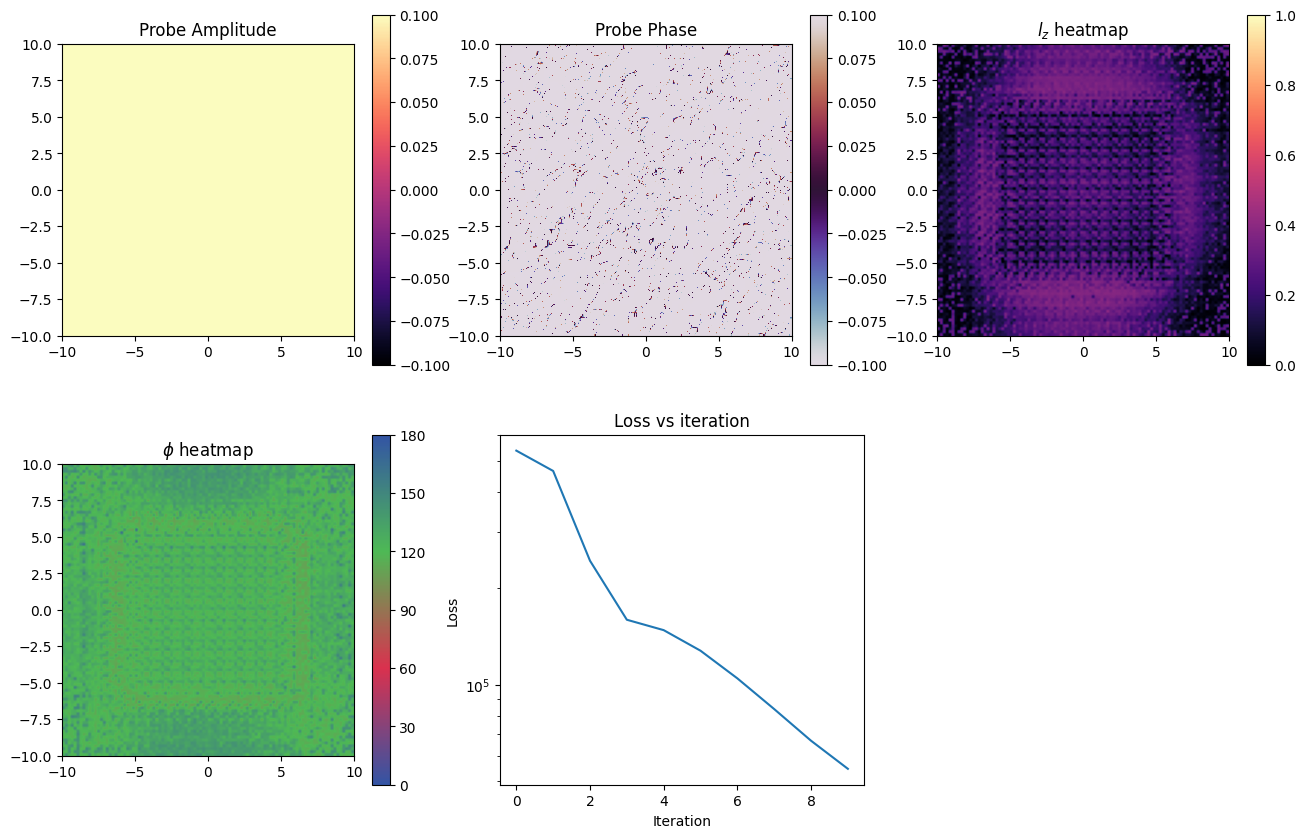

Calculated initial fluence from probe amplitude: 9.999999e+05, target fluence: 1.000000e+06
Calculated fluence from probe amplitude: 9.999999e+05, target fluence: 1.000000e+06
[0.5, 0.5, 1e-05, 6.0]
Iter    0 | Loss = 5.372790e+05
Calculated fluence from probe amplitude: 1.534438e+06, target fluence: 1.000000e+06
Iter    1 | Loss = 4.642554e+05
Calculated fluence from probe amplitude: 1.490166e+06, target fluence: 1.000000e+06
Iter    2 | Loss = 2.435248e+05
Calculated fluence from probe amplitude: 1.481600e+06, target fluence: 1.000000e+06
Iter    3 | Loss = 1.593520e+05
Calculated fluence from probe amplitude: 1.553258e+06, target fluence: 1.000000e+06
Iter    4 | Loss = 1.478849e+05
Calculated fluence from probe amplitude: 1.587452e+06, target fluence: 1.000000e+06
Iter    5 | Loss = 1.275569e+05
Calculated fluence from probe amplitude: 1.559669e+06, target fluence: 1.000000e+06
Iter    6 | Loss = 1.045689e+05
Calculated fluence from probe amplitude: 1.479815e+06, target fluence: 1.

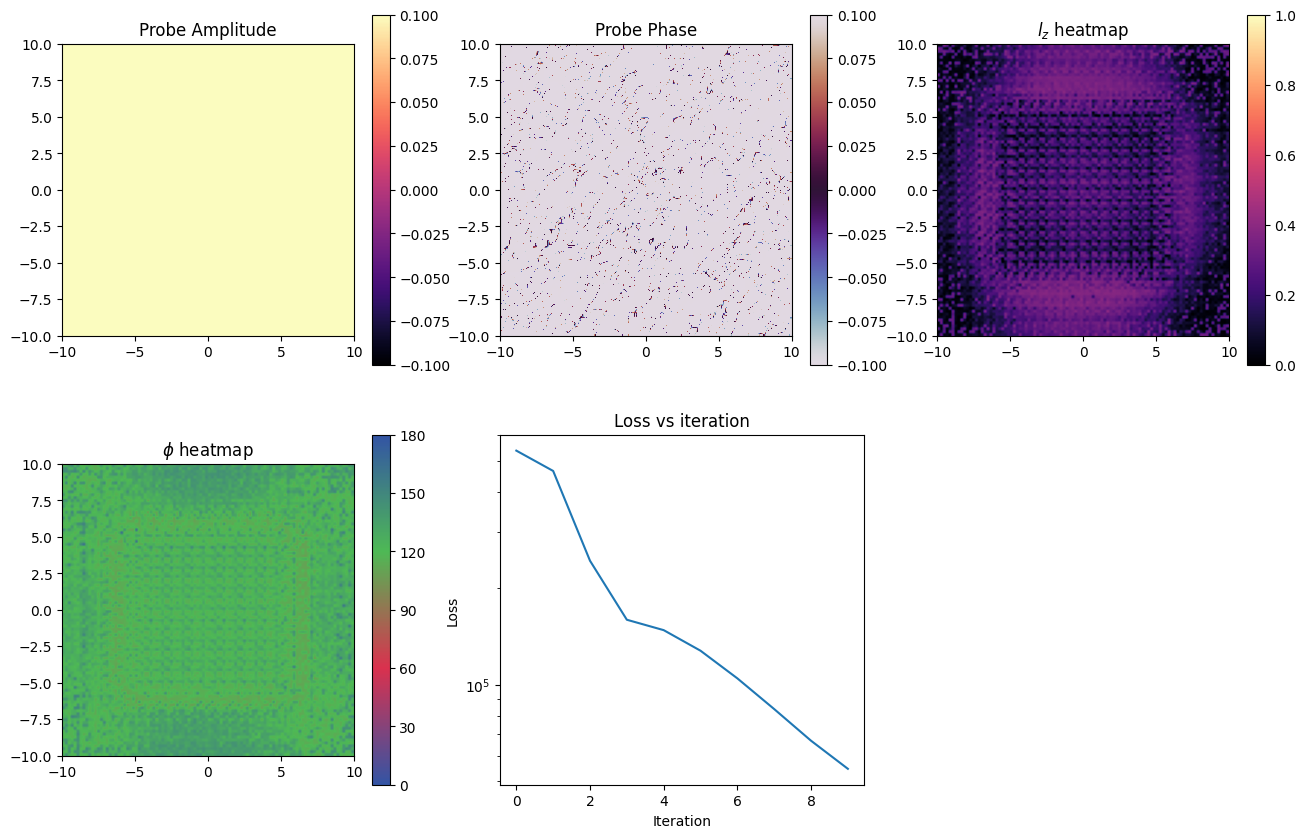

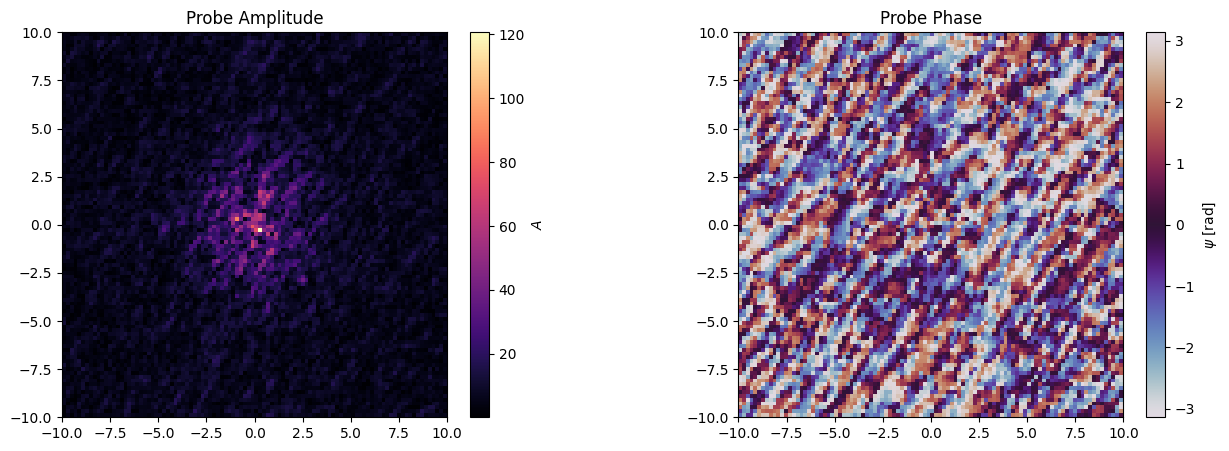

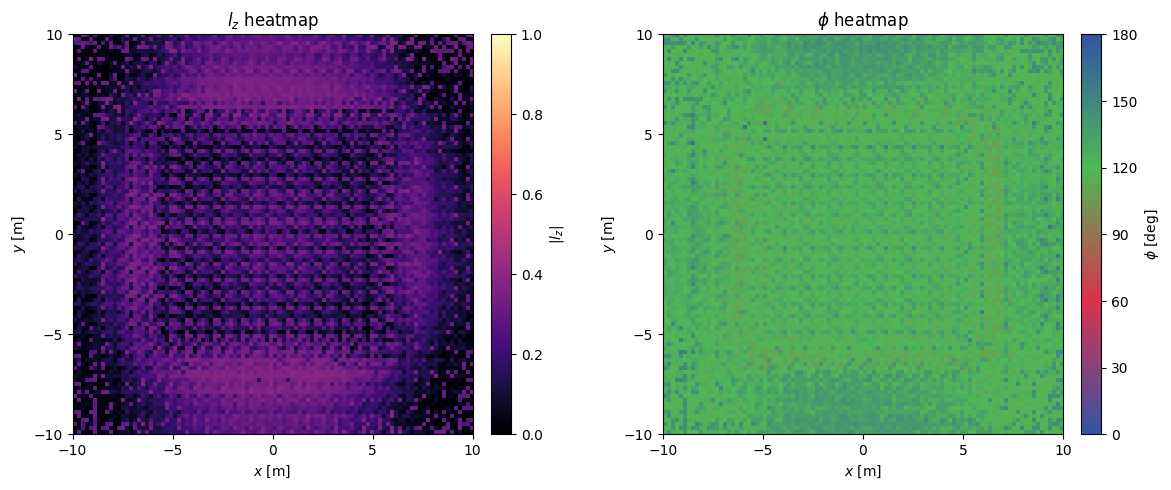

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '$l_z$ heatmap'}, xlabel='$x$ [m]', ylabel='$y$ [m]'>,
        <Axes: title={'center': '$\\phi$ heatmap'}, xlabel='$x$ [m]', ylabel='$y$ [m]'>],
       dtype=object))

In [ ]:
initial_theta = torch.nn.Parameter(torch.rand((H, W), device=device) * 0.01 + torch.pi/2)
initial_phi   = torch.nn.Parameter(torch.rand((H, W), device=device) * 0.1 + torch.pi/2)

P_test = torch.zeros_like(R)
Diffuser = torch.rand((H, W), device=device)
P_test = torch.exp(2j*np.pi*Diffuser)*(torch.exp(-0.8*R))
initial_probe_amplitude = P_test

result = optimize_object_and_probe_with_scheduler(scan, pol_angles, I_sim, H, W, initial_theta=initial_theta, 
                                   initial_phi=initial_phi, 
                                   initial_probe_amplitude=initial_probe_amplitude,
                                   num_iterations=10, device=device)



In [ ]:
plot_probe_maps(result["probe_amplitude"].detach().cpu().numpy(), Lx, Ly)
plot_theta_phi_maps(
    result["theta"].detach().cpu().numpy(),
    result["phi"].detach().cpu().numpy(),
    Lx,
    Ly,
    theta_cmap='magma',
    phi_cmap=RGB_scale,
    label_axes=True,
)

In [ ]:
plt.plot(result["loss_history"])
plt.ylabel('Loss')
plt.xlabel('Iteration')
plt.yscale('log')
plt.show()

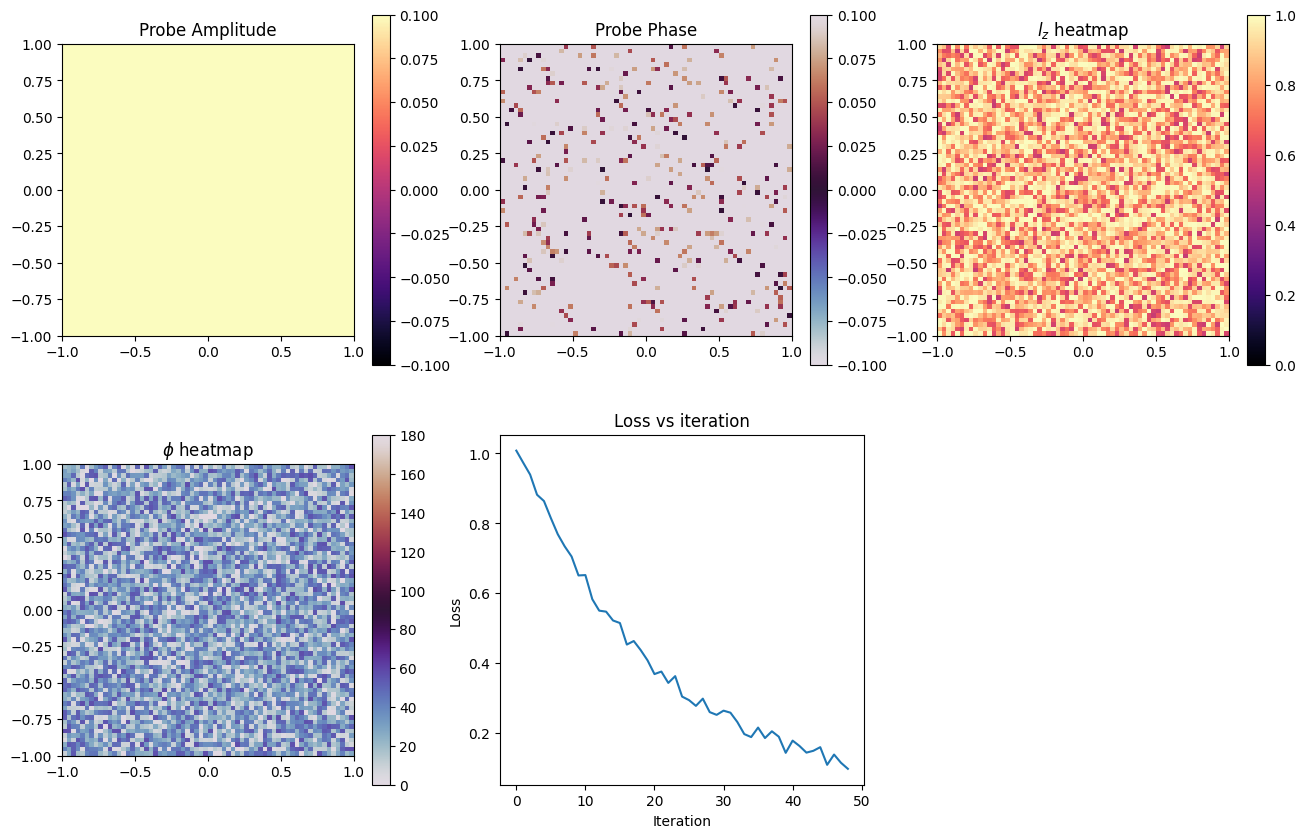

KeyboardInterrupt: 

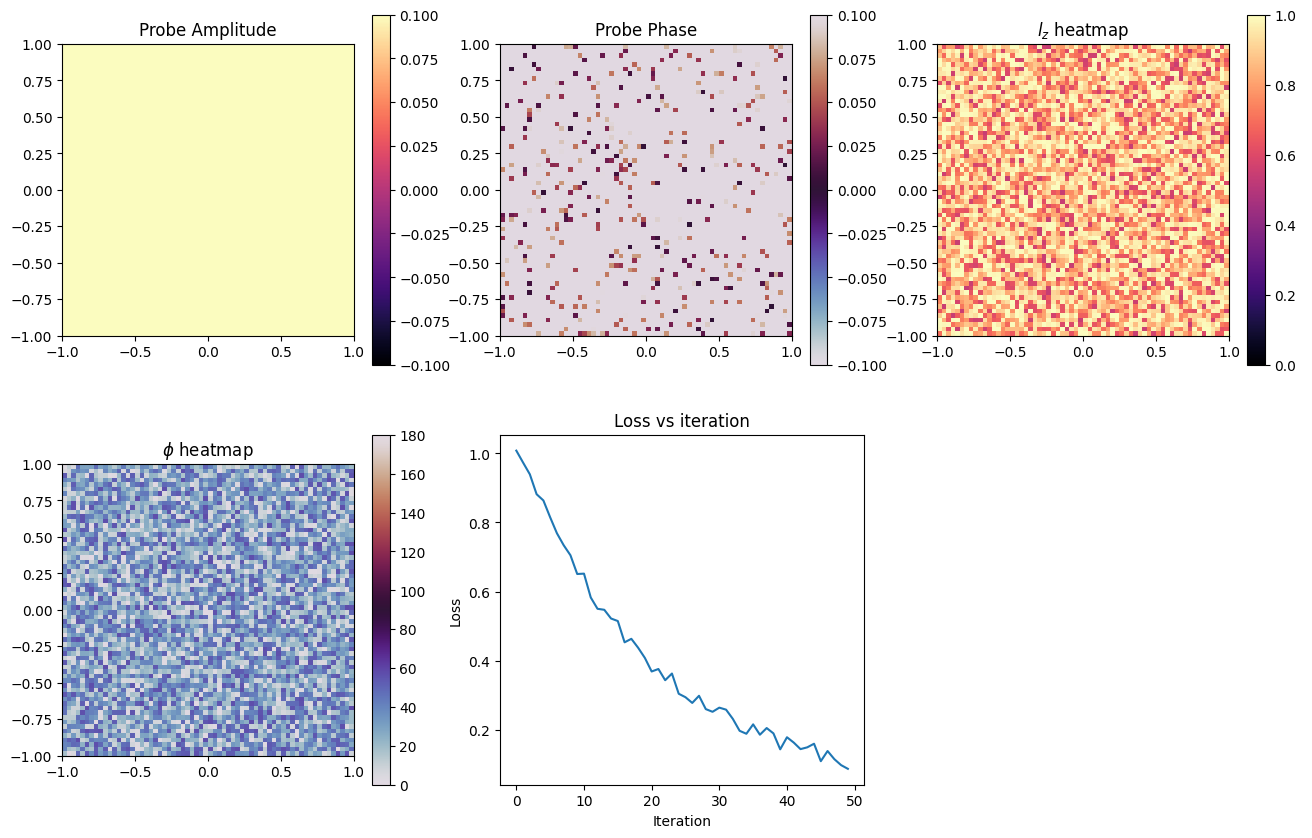

In [3]:
Lx = 1
Ly = 1
plot_update = create_live_plotter(Lx, Ly)

for i in range(100):

    probe = np.exp(1j * np.random.rand(64, 64))
    theta = np.random.rand(64, 64)
    phi   = np.random.rand(64, 64)

    loss = np.exp(-i / 20) + 0.05 * np.random.rand()

    plot_update(probe, theta, phi, loss)